Initializing data fetch...

Processing VRTX (1y)


[*********************100%***********************]  1 of 1 completed


Processing LULU (9mo)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Processing ODFL (6mo)



[*********************100%***********************]  1 of 1 completed

Processing ENPH (3mo)
Processing DKNG (1mo)



[*********************100%***********************]  1 of 1 completed



KPI Report:
  Ticker Period Last Data Point  Days Stale  Period Coverage (%)  \
0   VRTX     1y      2026-04-28           0                100.0   
1   LULU    9mo      2026-04-28           0                100.0   
2   ODFL    6mo      2026-04-28           0                100.0   
3   ENPH    3mo      2026-04-28           0                100.0   
4   DKNG    1mo      2026-04-28           0                100.0   

   Completeness (%)  Accuracy (%)  Suspicious Spikes  Volume Outliers  \
0             100.0         100.0                  0                0   
1             100.0         100.0                  0                0   
2             100.0         100.0                  0                0   
3             100.0         100.0                  1                0   
4             100.0         100.0                  0                0   

         Consistency  
0  5/5 checks passed  
1  5/5 checks passed  
2  5/5 checks passed  
3  5/5 checks passed  
4  5/5 checks passed  



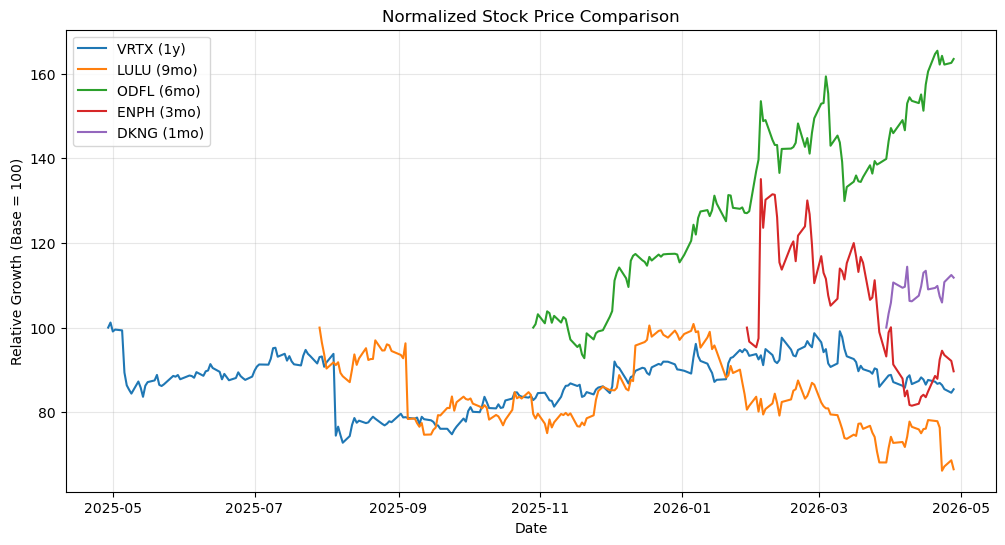


All files saved successfully.


In [1]:
# ==============================
# Imports and Setup
# ==============================
from datetime import date
import os
import time
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Create folders
os.makedirs("data", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# ==============================
# Configuration
# ==============================
configs = {
    'VRTX': '1y',
    'LULU': '9mo',
    'ODFL': '6mo',
    'ENPH': '3mo',
    'DKNG': '1mo'
}

kpi_results = []
all_data = {}

print("Initializing data fetch...\n")

# ==============================
# Data Collection and KPI Evaluation
# ==============================
for ticker, period in configs.items():
    print(f"Processing {ticker} ({period})")

    start_time = time.time()

    # Fetch raw data
    df_raw = yf.download(ticker, period=period)

    # KPI (a): Completeness (based on raw data)
    completeness = (1 - df_raw.isnull().sum().sum() / df_raw.size) * 100

    # Clean data
    df = df_raw.dropna()

    # KPI (b): Latency (Timeliness)
    today = pd.Timestamp(date.today())
    last_date = df.index[-1]
    first_date = df.index[0]
    days_stale = (today - last_date).days
    expected_days = (today - first_date).days
    actual_days = (last_date - first_date).days
    coverage_ratio = round((actual_days / expected_days) * 100, 2)

    # KPI (c): Accuracy
    invalid_negative = (df['Close'] <= 0) | (df['Volume'] < 0)
    invalid_ohlc = (
        (df['High'] < df['Low']) |
        (df['Close'] > df['High']) |
        (df['Close'] < df['Low']) |
        (df['Open'] > df['High']) |
        (df['Open'] < df['Low'])
    )
    price_change = df['Close'].pct_change().abs()
    suspicious_spikes = (price_change > 0.30).sum()
    volume_mean = df['Volume'].mean()
    volume_outliers = (df['Volume'] > 10 * volume_mean).sum()
    accuracy_issues = (invalid_negative | invalid_ohlc).sum().sum()
    accuracy_score = round((1 - accuracy_issues / len(df)) * 100, 2)

    # KPI (d): Consistency
    expected_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    schema_ok = all(col in df.columns for col in expected_cols)
    no_duplicates = not df.index.duplicated().any()
    dates_sorted = df.index.is_monotonic_increasing
    no_weekends = not any(df.index.dayofweek >= 5)
    types_consistent = all(
    pd.api.types.is_float_dtype(df[col].squeeze())
    for col in ['Open', 'High', 'Low', 'Close']
)
    consistency_score = sum([schema_ok, no_duplicates, dates_sorted, no_weekends, types_consistent])
    consistency_label = f"{consistency_score}/5 checks passed"

    # Store results
    kpi_results.append({
        'Ticker': ticker,
        'Period': period,
        'Last Data Point': last_date.date(),
        'Days Stale': days_stale,
        'Period Coverage (%)': coverage_ratio,
        'Completeness (%)': round(completeness, 2),
        'Accuracy (%)': accuracy_score,
        'Suspicious Spikes': int(suspicious_spikes.iloc[0]),
        'Volume Outliers': int(volume_outliers.iloc[0]),
        'Consistency': consistency_label
    })

    all_data[ticker] = df

# ==============================
# KPI Report
# ==============================
kpi_df = pd.DataFrame(kpi_results)

print("\nKPI Report:")
print(kpi_df)

# Save KPI report
kpi_df.to_csv("kpi_report.csv", index=False)

# ==============================
# Descriptive Statistics
# ==============================
print("\nDescriptive Statistics for VRTX (1 Year):\n")
print(all_data['VRTX'].describe().round(2))

# ==============================
# Visualization
# ==============================
plt.figure(figsize=(12, 6))

for ticker, df in all_data.items():
    normalized_price = (df['Close'] / df['Close'].iloc[0]) * 100
    plt.plot(df.index, normalized_price, label=f"{ticker} ({configs[ticker]})")

plt.title("Normalized Stock Price Comparison")
plt.xlabel("Date")
plt.ylabel("Relative Growth (Base = 100)")
plt.legend()
plt.grid(alpha=0.3)

# Save plot before displaying
plt.savefig("plots/price_comparison.png")
plt.show()

# ==============================
# Save Individual Datasets
# ==============================
for ticker, df in all_data.items():
    df.to_csv(f"data/{ticker}.csv")

print("\nAll files saved successfully.")